# Vocabulary Level Prediction — model selection

## 0. Environment

`importlib.reload` on `utils` / `modeling_utils` after editing those files (same pattern as [EDA.ipynb](EDA.ipynb)).

In [26]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display

# Load project modules first, then reload so edits to .py files apply without kernel restart.
import modeling_utils
import utils

importlib.reload(utils)
importlib.reload(modeling_utils)

from modeling_utils import (
    filter_by_rater_agreement,
    create_consensus_target,
    build_text_target_dataset,
    build_stratification_bins,
    build_experiment_registry,
    DEFAULT_TFIDF_VECTORIZER_KWARGS,
    run_all_experiments_cv,
    build_cv_leaderboard,
    style_cv_leaderboard,
    plot_cv_metric_bars,
    plot_cv_fold_boxplot,
    optuna_tune_tfidf_mlp,
    optuna_tune_tfidf_mlp_svd_n_components,
    rank_optuna_trials_like_cv_leaderboard,
    parse_optuna_mlp_hidden_layer_sizes,
    make_tfidf_mlp_pipeline,
    evaluate_fold,
    compute_balanced_sample_weights,
    round_and_clip_predictions,
    plot_ordinal_predicted_vs_true_scatter,
    plot_ordinal_continuous_boxplot_by_true_class,
    plot_row_normalized_confusion_matrix_from_labels,

    UniformRandomScoreRegressor,
)
from utils import (
    get_text_length_features_df,
    get_vocabulary_richness_df,
    get_essay_embeddings,
)
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.svm import LinearSVR

try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

pd.set_option("display.max_colwidth", None)

## 1. Load data

Training CSV: `Data/train.csv`.

In [3]:
df_train = pd.read_csv("Data/train.csv")
print(f"Train: {len(df_train)} rows")

Train: 7112 rows


## 2. Preprocessing

Agreement filter (drop rows with `|V1-V2| >= 2`); consensus target → `target_vocab`.

In [4]:
rows_before = len(df_train)
df_train = filter_by_rater_agreement(df_train)
print(f"Removed {rows_before - len(df_train)} rows (|V1-V2| >= 2), kept {len(df_train)}")

Removed 308 rows (|V1-V2| >= 2), kept 6804


In [5]:
df_train = create_consensus_target(df_train)
df_train["target_vocab"].value_counts().sort_index()

target_vocab
0      11
1       1
2    1270
3    2343
4    3114
5      65
Name: count, dtype: int64

In [6]:
df_train_text_target = build_text_target_dataset(df_train)
# df_train_text_target.head()

## 3. Precomputed label-free features

- Label-free only (`Text_cleaned` / frozen encoder); no `target_vocab` in these matrices.
- Learned steps (TF-IDF, scalers, SVD): **fit inside CV folds** only.

### 3.1 Handcrafted

Four columns from EDA helpers on `Text_cleaned`: `unique_words`, `sentence_count`, `char_count`, `word_count`.

In [7]:
length_features_df = get_text_length_features_df(df_train_text_target, text_column="Text_cleaned")
richness_features_df = get_vocabulary_richness_df(df_train_text_target, text_column="Text_cleaned")

X_handcrafted_precomputed = pd.DataFrame(
    {
        "unique_words": richness_features_df["unique_words"],
        "sentence_count": length_features_df["sentence_count"],
        "char_count": length_features_df["char_count"],
        "word_count": length_features_df["word_count"],
    },
    index=df_train_text_target.index,
)
X_handcrafted_precomputed.head()

,unique_words,sentence_count,char_count,word_count
0,115,7,1281,254
1,162,15,2232,448
2,100,6,843,172
3,105,15,1777,351
4,108,7,1025,181


### 3.2 Sentence embeddings

`get_essay_embeddings(..., use_fast_model=True)` — MiniLM-L3, CPU-friendly; inference-only, no fine-tuning. Row order aligned with `df_train_text_target`.

In [8]:
X_embeddings_precomputed = get_essay_embeddings(
    df=df_train_text_target,
    text_column="Text_cleaned",
    use_fast_model=True,
    batch_size=256,
)
X_embeddings_precomputed.shape

Loading weights: 100%|██████████| 55/55 [00:00<00:00, 2752.86it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L3-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 492/492 [06:17<00:00,  1.30it/s]


(6804, 384)

## 4. Model Selection

- **CV:** one stratified 5-fold (`shuffle=True`, `random_state=42`) shared across all experiments.
- **Hyperparams:** hand-picked starting points in code (no grid here); XGB `tree_method="hist"`, LGBM `verbosity=-1`; tree models use fold **numpy** features.
- **Experiments:** `random_baseline_U01` (uniform [0,5]); `handcrafted_Ridge` (4 handcrafted cols); TF-IDF track (Ridge/Lasso/EN/LinearSVR/XGB/LGBM/MLP; **no RF**); TF-IDF MLP = `TfidfVectorizer` → `TruncatedSVD` → `MLPRegressor`; embedding track = same model families on 384-d vectors (scaler for linear/MLP, none for trees).
- **Metrics:** mean QWK (preds rounded/clipped to 0–5), RMSE, MAE vs integer `y`.
- **Leakage control:** TF-IDF/StandardScaler/SVD fit on train fold only; `sample_weight` from fold labels. **Stratification:** bins 0 and 1 merged for fold assignment (rare classes).

In [9]:
# --- Experiment registry (Section 4) ---
# Reasonable starting points (not Optuna): regularization for text/high-dim, convergence budgets,
# and moderate boosting. `random_state` for reproducibility. XGB/LGB: fold features are
# passed as numpy inside CV (not controlled here), which avoids feature-name warnings.
CV_RANDOM_STATE = 42

HANDCRAFTED_BASELINE_ESTIMATORS = [
    # alpha=0.1: sklearn default 1.0 is stiff for four raw count features.
    # solver='lsqr': works with sparse TF-IDF + intercept; stable for small dense handcrafted matrices.
    ("Ridge", Ridge(alpha=0.1, solver="lsqr", random_state=CV_RANDOM_STATE)),
]

FULL_MODEL_ESTIMATORS = [
    # alpha=0.1: milder L2 than default 1.0 for high-dim text.
    # solver='lsqr': sklearn forbids solver='svd' on sparse TF-IDF (intercept); lsqr supports sparse+dense.
    ("Ridge", Ridge(alpha=0.1, solver="lsqr", random_state=CV_RANDOM_STATE)),
    (
        "Lasso",
        Lasso(
            alpha=0.001,
            max_iter=5000,
            tol=1e-3,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    (
        "ElasticNet",
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=50000,  # coordinate descent did not converge at 5000 on 384-d embeddings; still <1 s
            tol=1e-3,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    (
        "LinearSVR",
        # max_iter=50000: liblinear did not converge at 8000 on 384-d embeddings; trivial runtime on small d
        LinearSVR(max_iter=50000, C=0.5, dual=True),
    ),
    (
        "MLP",
        MLPRegressor(
            hidden_layer_sizes=(256,),
            max_iter=500,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=CV_RANDOM_STATE,
        ),
    ),
    # TF-IDF path: TfidfVectorizer -> TruncatedSVD -> MLP; early_stopping caps wall time.
]
if XGBRegressor is not None:
    FULL_MODEL_ESTIMATORS.append(
        (
            "XGB",
            XGBRegressor(
                # Library defaults for n_estimators, max_depth, learning_rate, subsample, etc.
                # Only set: reproducibility, parallelism, and hist (fast on high-dim sparse; not shallower trees).
                tree_method="hist",
                random_state=CV_RANDOM_STATE,
                n_jobs=-1,
            ),
        )
    )
if LGBMRegressor is not None:
    FULL_MODEL_ESTIMATORS.append(
        (
            "LGBM",
            LGBMRegressor(
                random_state=CV_RANDOM_STATE,
                n_jobs=-1,
                verbosity=-1,
            ),
        )
    )

TRACK_SPECS = [
    {
        "feature_source": "random_uniform",
        "name_prefix": "random_baseline",
        "named_estimators": [
            (
                "U01",
                UniformRandomScoreRegressor(
                    random_state=CV_RANDOM_STATE,
                    min_score=0.0,
                    max_score=5.0,
                ),
            ),
        ],
    },
    {
        "feature_source": "handcrafted",
        "name_prefix": "handcrafted",
        "named_estimators": HANDCRAFTED_BASELINE_ESTIMATORS,
    },
    {
        "feature_source": "tfidf",
        "name_prefix": "tfidf",
        "named_estimators": FULL_MODEL_ESTIMATORS,
    },
    {
        "feature_source": "embeddings",
        "name_prefix": "emb",
        "named_estimators": FULL_MODEL_ESTIMATORS,
    },
]

TFIDF_KWARGS = dict(DEFAULT_TFIDF_VECTORIZER_KWARGS)

experiment_registry = build_experiment_registry(
    track_specs=TRACK_SPECS,
    tfidf_vectorizer_kwargs=TFIDF_KWARGS,
    svd_n_components=300,
    tfidf_mlp_short_name="MLP",
)
# Show every experiment name 
len(experiment_registry), [exp["name"] for exp in experiment_registry]

(16,
 ['random_baseline_U01',
  'handcrafted_Ridge',
  'tfidf_Ridge',
  'tfidf_Lasso',
  'tfidf_ElasticNet',
  'tfidf_LinearSVR',
  'tfidf_MLP',
  'tfidf_XGB',
  'tfidf_LGBM',
  'emb_Ridge',
  'emb_Lasso',
  'emb_ElasticNet',
  'emb_LinearSVR',
  'emb_MLP',
  'emb_XGB',
  'emb_LGBM'])

In [10]:
# Targets and stratification bins (bins used only for fold assignment).
y = df_train_text_target["target_vocab"].values
stratification_bins = build_stratification_bins(y, merge_below=2)

# Row-aligned inputs per feature_source. "tfidf" must be raw text — vectorizer fits inside each fold.
_handcrafted_xy = X_handcrafted_precomputed.reset_index(drop=True)
feature_data_by_source = {
    "random_uniform": _handcrafted_xy,
    "handcrafted": _handcrafted_xy,
    "tfidf": df_train_text_target["Text_cleaned"].reset_index(drop=True),
    "embeddings": np.asarray(X_embeddings_precomputed),
}

In [82]:
all_fold_results = run_all_experiments_cv(
    experiments=experiment_registry,
    target_values=y,
    feature_data_by_source=feature_data_by_source,
    stratification_bins=stratification_bins,
    n_splits=5,
    random_state=42,
    use_sample_weights=True,
)
all_fold_results

  Running: random_baseline_U01 ... mean QWK=0.0095, RMSE=1.8378, MAE=1.5096
  Running: handcrafted_Ridge ... mean QWK=0.3451, RMSE=1.0546, MAE=0.8607
  Running: tfidf_Ridge ... mean QWK=0.4661, RMSE=0.7182, MAE=0.5755
  Running: tfidf_Lasso ... mean QWK=0.4137, RMSE=0.7492, MAE=0.6011
  Running: tfidf_ElasticNet ... mean QWK=0.4130, RMSE=0.6864, MAE=0.5588
  Running: tfidf_LinearSVR ... mean QWK=0.4990, RMSE=0.6903, MAE=0.5562
  Running: tfidf_MLP ... mean QWK=0.5113, RMSE=0.6793, MAE=0.5438
  Running: tfidf_XGB ... mean QWK=0.4229, RMSE=0.7226, MAE=0.5844
  Running: tfidf_LGBM ... mean QWK=0.4300, RMSE=0.6895, MAE=0.5622
  Running: emb_Ridge ... mean QWK=0.4238, RMSE=0.7998, MAE=0.6339
  Running: emb_Lasso ... mean QWK=0.4239, RMSE=0.7874, MAE=0.6249
  Running: emb_ElasticNet ... mean QWK=0.4234, RMSE=0.7888, MAE=0.6259
  Running: emb_LinearSVR ... 

c:\Users\gilad\CursorProjects\Vocabulary Level Prediction\.venv\lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


mean QWK=0.4094, RMSE=0.8899, MAE=0.7008
  Running: emb_MLP ... mean QWK=0.3936, RMSE=0.7772, MAE=0.6258
  Running: emb_XGB ... mean QWK=0.2888, RMSE=0.7726, MAE=0.6277
  Running: emb_LGBM ... mean QWK=0.2987, RMSE=0.7309, MAE=0.6063


,experiment,fold,qwk,rmse,mae
0,random_baseline_U01,1,0.005546,1.843051,1.519984
1,random_baseline_U01,2,0.010323,1.834963,1.503791
2,random_baseline_U01,3,0.002478,1.847542,1.508232
3,random_baseline_U01,4,-0.021297,1.863664,1.539941
4,random_baseline_U01,5,0.050642,1.799537,1.476224
...,...,...,...,...,...
75,emb_LGBM,1,0.311245,0.723088,0.602613
76,emb_LGBM,2,0.312432,0.711940,0.593583
77,emb_LGBM,3,0.292369,0.729576,0.600070
78,emb_LGBM,4,0.285873,0.748228,0.618713


In [83]:
# Aggregate fold metrics: mean/std per experiment, sort by QWK then MAE.
cv_leaderboard = build_cv_leaderboard(all_fold_results)
style_cv_leaderboard(cv_leaderboard)

,experiment,qwk_mean,qwk_std,rmse_mean,rmse_std,mae_mean,mae_std
0,tfidf_MLP,0.5113,0.0076,0.6793,0.0195,0.5438,0.0184
1,tfidf_LinearSVR,0.4990,0.0118,0.6903,0.0203,0.5562,0.0159
2,tfidf_Ridge,0.4661,0.0101,0.7182,0.0111,0.5755,0.0088
3,tfidf_LGBM,0.4300,0.0107,0.6895,0.0085,0.5622,0.0051
4,emb_Lasso,0.4239,0.0165,0.7874,0.0118,0.6249,0.0093
5,emb_Ridge,0.4238,0.0166,0.7998,0.0123,0.6339,0.0097
6,emb_ElasticNet,0.4234,0.0174,0.7888,0.0128,0.6259,0.0100
7,tfidf_XGB,0.4229,0.0228,0.7226,0.0063,0.5844,0.0066
8,tfidf_Lasso,0.4137,0.0035,0.7492,0.0226,0.6011,0.0184
9,tfidf_ElasticNet,0.4130,0.0093,0.6864,0.0152,0.5588,0.0117


### 4.1 CV metric plots

Bars: mean ± std per metric. Boxplot: per-fold QWK.

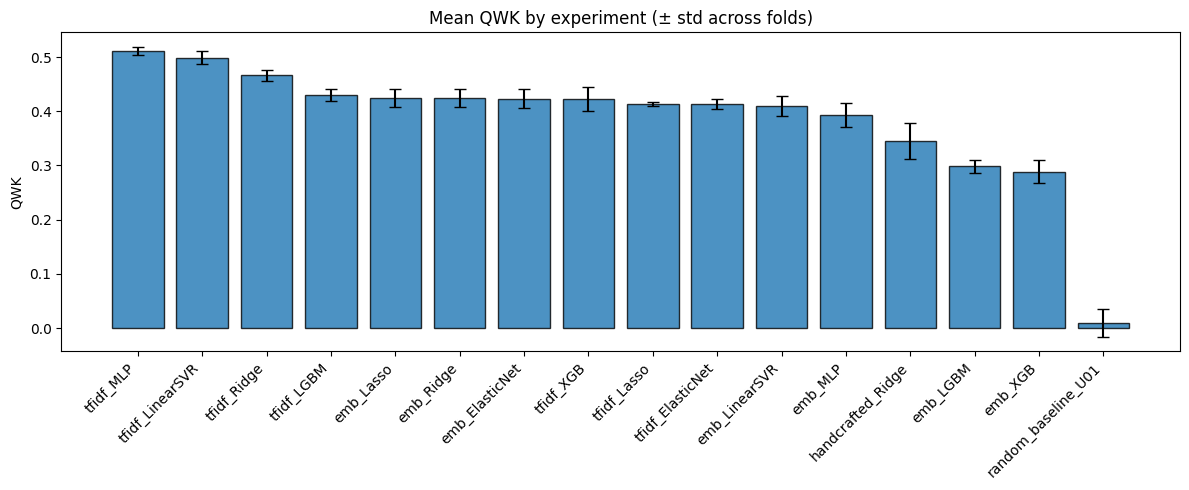

In [84]:
fig_qwk = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="qwk_mean",
    metric_std_col="qwk_std",
    title="Mean QWK by experiment (± std across folds)",
    ylabel="QWK",
    higher_is_better=True,
)
plt.show()

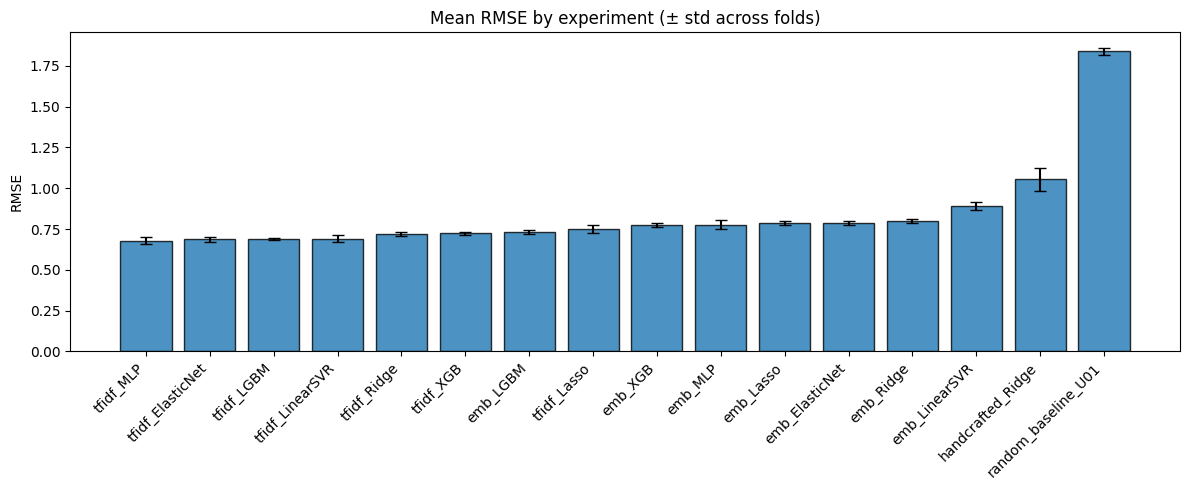

In [85]:
fig_rmse = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="rmse_mean",
    metric_std_col="rmse_std",
    title="Mean RMSE by experiment (± std across folds)",
    ylabel="RMSE",
    higher_is_better=False,
)
plt.show()

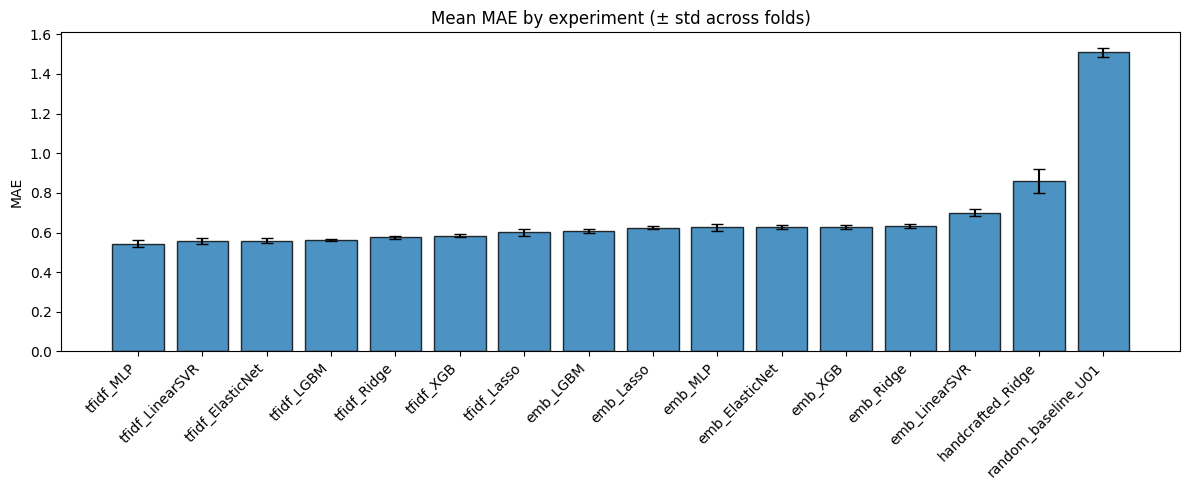

In [ ]:
fig_mae = plot_cv_metric_bars(
    cv_leaderboard,
    metric_mean_col="mae_mean",
    metric_std_col="mae_std",
    title="Mean MAE by experiment (± std across folds)",
    ylabel="MAE",
    higher_is_better=False,
)
plt.show()

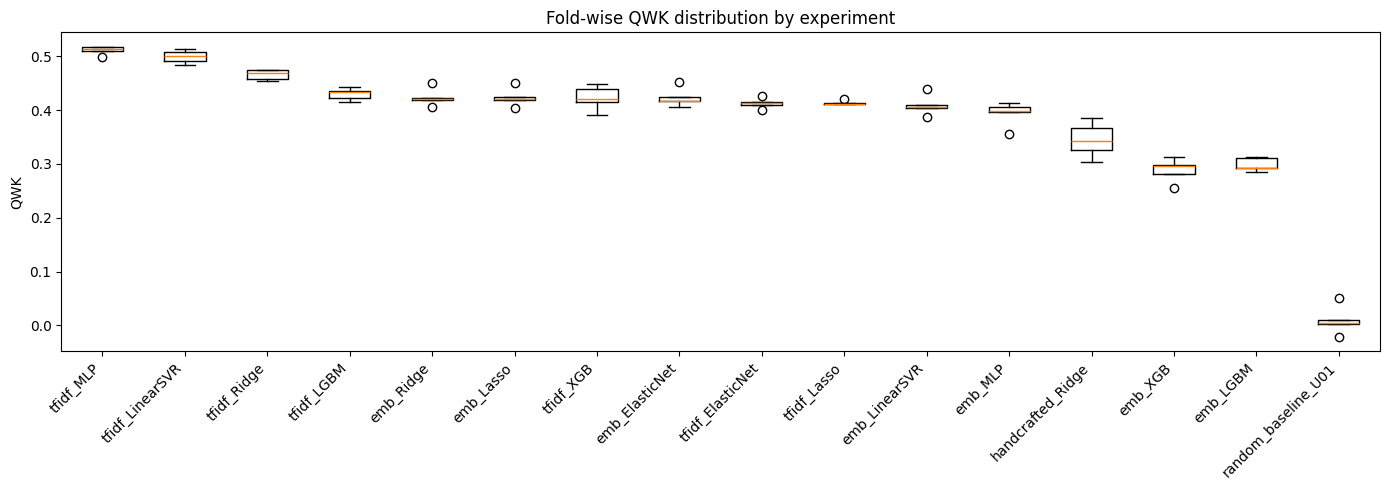

In [87]:
fig_box_qwk = plot_cv_fold_boxplot(all_fold_results, metric="qwk")
plt.show()

### 4.2 Winner selection

**Classical winner:** `cv_leaderboard` sorted by `qwk_mean` desc, then `mae_mean` asc (first row).

In [ ]:
# Summary of the best classical experiment (for reporting / downstream use).
CLASSICAL_CV_WINNER_EXPERIMENT = cv_leaderboard.iloc[0]["experiment"]
CLASSICAL_CV_WINNER_QWK_MEAN = float(cv_leaderboard.iloc[0]["qwk_mean"])
CLASSICAL_CV_WINNER_MAE_MEAN = float(cv_leaderboard.iloc[0]["mae_mean"])

CLASSICAL_CV_WINNER_EXPERIMENT, CLASSICAL_CV_WINNER_QWK_MEAN, CLASSICAL_CV_WINNER_MAE_MEAN

('tfidf_MLP', 0.5112696759044011, 0.5438126862677615)

## 5. Hyperparameter tuning (TF-IDF + SVD + MLP)

- **Scope:** Optuna on TF-IDF → SVD → MLP only; independent of Section 4 ranking. Needs `feature_data_by_source["tfidf"]`, `y`, `TFIDF_KWARGS`, `stratification_bins`.
- **Fixed:** `TFIDF_KWARGS` (vectorizer not tuned). Subsample / fewer folds in Optuna for speed; full CV for final numbers if needed.
- **Objective:** mean QWK (same weighting / rounding as registry CV).
- **Phases:** A — fixed SVD width (registry), TPE on MLP. B — freeze Phase-A MLP, TPE on `svd_n_components` (cheaper than joint search).


### 5.1 Phase A — Optuna (MLP, fixed SVD)

Knobs: `N_OPTUNA_TRIALS`, `N_CV_SPLITS_OPTUNA`, `OPTUNA_OBJECTIVE_SUBSAMPLE_N` (`None` = full data). `limit_blas_threads=True` — easier interrupt on long fits.


In [13]:
# Phase A: TPE on MLP; fixed SVD width (match registry default svd_n_components=300).
# Uses TFIDF_KWARGS from earlier cells. Speed = stratified subsample + fewer folds (optional).
if "feature_data_by_source" not in globals() or "tfidf" not in feature_data_by_source:
    raise RuntimeError(
        "Section 5 needs feature_data_by_source['tfidf'] — run data prep / TF-IDF cells first."
    )

N_OPTUNA_TRIALS = 15
N_CV_SPLITS_OPTUNA = 5  # set to 5 to match main CV fold count if desired
# None = full training set (slow). Integer = stratified subsample for faster trials.
OPTUNA_OBJECTIVE_SUBSAMPLE_N = min(6000, len(feature_data_by_source["tfidf"]))
SVD_FIXED = 300

optuna_study, optuna_trials_df = optuna_tune_tfidf_mlp(
    raw_text_series=feature_data_by_source["tfidf"],
    target_values=y,
    stratification_bins=stratification_bins,
    vectorizer_kwargs=TFIDF_KWARGS,
    svd_n_components=SVD_FIXED,
    mlp_fixed_kwargs=None,
    n_trials=N_OPTUNA_TRIALS,
    n_splits=N_CV_SPLITS_OPTUNA,
    random_state=CV_RANDOM_STATE,
    use_sample_weights=True,
    optuna_seed=CV_RANDOM_STATE,
    use_pruner=True,
    verbose_cv=True,
    limit_blas_threads=True,
    show_progress_bar=True,
    objective_subsample_n=OPTUNA_OBJECTIVE_SUBSAMPLE_N,
)
display(rank_optuna_trials_like_cv_leaderboard(optuna_trials_df).head(15))


Optuna objective uses stratified subsample: n=6000 of 6804 rows (faster trials).


[I 2026-03-21 16:49:55,896] A new study created in memory with name: no-name-9becd916-5b38-4b53-8c46-54fd44d4f377
  0%|          | 0/15 [00:00<?, ?it/s]


Optuna trial 1/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5126 RMSE=0.6598 MAE=0.5348
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.4834 RMSE=0.6770 MAE=0.5438
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4939 RMSE=0.6646 MAE=0.5226
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4006 RMSE=0.7587 MAE=0.5997
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5191 RMSE=0.6612 MAE=0.5284


Best trial: 0. Best value: 0.481927:   7%|▋         | 1/15 [01:55<27:03, 115.95s/it]

[I 2026-03-21 16:51:51,713] Trial 0 finished with value: 0.48192669054040105 and parameters: {'hidden_layer_sizes': '256', 'alpha': 4.207988669606632e-05, 'learning_rate_init': 0.00026364803038431676, 'batch_size': 64, 'max_iter': 310, 'activation': 'relu'}. Best is trial 0 with value: 0.48192669054040105.

Optuna trial 2/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5214 RMSE=0.6714 MAE=0.5330
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5409 RMSE=0.6847 MAE=0.5394
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4964 RMSE=0.7116 MAE=0.5581
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4962 RMSE=0.7135 MAE=0.5654
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.4776 RMSE=0.6839 MAE=0.5366


Best trial: 1. Best value: 0.506499:  13%|█▎        | 2/15 [03:21<21:13, 97.98s/it] 

[I 2026-03-21 16:53:17,119] Trial 1 finished with value: 0.5064986710514722 and parameters: {'hidden_layer_sizes': '256x128', 'alpha': 0.0012561043700013551, 'learning_rate_init': 0.0014648955132800737, 'batch_size': 64, 'max_iter': 483, 'activation': 'tanh'}. Best is trial 1 with value: 0.5064986710514722.

Optuna trial 3/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4975 RMSE=0.6888 MAE=0.5471
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.0133 RMSE=1.3835 MAE=1.2059
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4881 RMSE=0.6969 MAE=0.5486
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4800 RMSE=0.7328 MAE=0.5818
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5179 RMSE=0.6729 MAE=0.5363


Best trial: 1. Best value: 0.506499:  20%|██        | 3/15 [07:34<33:44, 168.70s/it]

[I 2026-03-21 16:57:29,954] Trial 2 finished with value: 0.3993742184219365 and parameters: {'hidden_layer_sizes': '512', 'alpha': 0.0026926469100861782, 'learning_rate_init': 0.00028856223618597374, 'batch_size': 128, 'max_iter': 452, 'activation': 'tanh'}. Best is trial 1 with value: 0.5064986710514722.

Optuna trial 4/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5265 RMSE=0.6545 MAE=0.5213
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5282 RMSE=0.6835 MAE=0.5492
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4928 RMSE=0.6791 MAE=0.5372
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4777 RMSE=0.6960 MAE=0.5602
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5192 RMSE=0.6519 MAE=0.5184


Best trial: 3. Best value: 0.508879:  27%|██▋       | 4/15 [13:09<42:58, 234.45s/it]

[I 2026-03-21 17:03:05,197] Trial 3 finished with value: 0.5088789335367576 and parameters: {'hidden_layer_sizes': '512', 'alpha': 0.04337920697490941, 'learning_rate_init': 0.0004993895014755662, 'batch_size': 32, 'max_iter': 392, 'activation': 'relu'}. Best is trial 3 with value: 0.5088789335367576.

Optuna trial 5/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5288 RMSE=0.6619 MAE=0.5268
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.0699 RMSE=1.2343 MAE=1.0739
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4877 RMSE=0.6741 MAE=0.5327
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5034 RMSE=0.6834 MAE=0.5443
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.4909 RMSE=0.6917 MAE=0.5436


Best trial: 3. Best value: 0.508879:  33%|███▎      | 5/15 [14:29<29:47, 178.77s/it]

[I 2026-03-21 17:04:25,257] Trial 4 finished with value: 0.41614971653352245 and parameters: {'hidden_layer_sizes': '128', 'alpha': 2.259279742015695e-05, 'learning_rate_init': 0.00033802737047124425, 'batch_size': 128, 'max_iter': 715, 'activation': 'relu'}. Best is trial 3 with value: 0.5088789335367576.

Optuna trial 6/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4950 RMSE=0.7109 MAE=0.5659


Best trial: 3. Best value: 0.508879:  40%|████      | 6/15 [14:49<18:43, 124.88s/it]

[I 2026-03-21 17:04:45,522] Trial 5 pruned. 

Optuna trial 7/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...


c:\Users\gilad\CursorProjects\Vocabulary Level Prediction\.venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


  CV fold 1/5: QWK=0.5303 RMSE=0.6731 MAE=0.5371
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.0462 RMSE=1.2861 MAE=1.1181
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4826 RMSE=0.6698 MAE=0.5329
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4447 RMSE=0.7013 MAE=0.5489
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5206 RMSE=0.6529 MAE=0.5195


Best trial: 3. Best value: 0.508879:  47%|████▋     | 7/15 [19:42<23:58, 179.84s/it]

[I 2026-03-21 17:09:38,515] Trial 6 finished with value: 0.4048757062584915 and parameters: {'hidden_layer_sizes': '512', 'alpha': 0.00021066486017042195, 'learning_rate_init': 0.00014843697010415803, 'batch_size': 128, 'max_iter': 744, 'activation': 'relu'}. Best is trial 3 with value: 0.5088789335367576.

Optuna trial 8/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4936 RMSE=0.6943 MAE=0.5445


Best trial: 3. Best value: 0.508879:  53%|█████▎    | 8/15 [20:00<14:56, 128.14s/it]

[I 2026-03-21 17:09:55,942] Trial 7 pruned. 

Optuna trial 9/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5288 RMSE=0.6645 MAE=0.5288
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.0759 RMSE=1.2280 MAE=1.0686
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4986 RMSE=0.6704 MAE=0.5294
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4987 RMSE=0.6833 MAE=0.5425
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5099 RMSE=0.6741 MAE=0.5301


Best trial: 3. Best value: 0.508879:  60%|██████    | 9/15 [21:41<11:57, 119.65s/it]

[I 2026-03-21 17:11:36,932] Trial 8 finished with value: 0.42238797611216106 and parameters: {'hidden_layer_sizes': '128', 'alpha': 8.226074946221034e-05, 'learning_rate_init': 0.00016134907038916252, 'batch_size': 128, 'max_iter': 617, 'activation': 'relu'}. Best is trial 3 with value: 0.5088789335367576.

Optuna trial 10/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5129 RMSE=0.6851 MAE=0.5490


Best trial: 3. Best value: 0.508879:  67%|██████▋   | 10/15 [22:00<07:23, 88.68s/it]

[I 2026-03-21 17:11:56,260] Trial 9 pruned. 

Optuna trial 11/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5252 RMSE=0.6729 MAE=0.5344


Best trial: 3. Best value: 0.508879:  73%|███████▎  | 11/15 [22:33<04:46, 71.74s/it]

[I 2026-03-21 17:12:29,605] Trial 10 pruned. 

Optuna trial 12/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5204 RMSE=0.6819 MAE=0.5415


Best trial: 3. Best value: 0.508879:  80%|████████  | 12/15 [22:49<02:44, 54.77s/it]

[I 2026-03-21 17:12:45,555] Trial 11 pruned. 

Optuna trial 13/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5444 RMSE=0.6898 MAE=0.5466
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5469 RMSE=0.6810 MAE=0.5375
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.5057 RMSE=0.6780 MAE=0.5298
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4466 RMSE=0.7053 MAE=0.5742
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5062 RMSE=0.7004 MAE=0.5644


Best trial: 12. Best value: 0.509974:  87%|████████▋ | 13/15 [24:39<02:22, 71.36s/it]

[I 2026-03-21 17:14:35,087] Trial 12 finished with value: 0.509974274676081 and parameters: {'hidden_layer_sizes': '256x128', 'alpha': 0.0005663422901520231, 'learning_rate_init': 0.0012839685314277372, 'batch_size': 32, 'max_iter': 457, 'activation': 'tanh'}. Best is trial 12 with value: 0.509974274676081.

Optuna trial 14/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5024 RMSE=0.6969 MAE=0.5399


Best trial: 12. Best value: 0.509974:  93%|█████████▎| 14/15 [24:57<00:55, 55.28s/it]

[I 2026-03-21 17:14:53,220] Trial 13 pruned. 

Optuna trial 15/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4482 RMSE=0.7107 MAE=0.5824


Best trial: 12. Best value: 0.509974: 100%|██████████| 15/15 [25:28<00:00, 101.89s/it]

[I 2026-03-21 17:15:24,158] Trial 14 pruned. 


,number,state,qwk_mean,rmse_mean,mae_mean,value,hidden_layer_sizes,alpha,learning_rate_init,batch_size,max_iter,activation
0,12,TrialState.COMPLETE,0.509974,0.690912,0.550505,0.509974,256x128,0.000566,0.001284,32,457,tanh
1,3,TrialState.COMPLETE,0.508879,0.673002,0.537250,0.508879,512,0.043379,0.000499,32,392,relu
2,1,TrialState.COMPLETE,0.506499,0.693021,0.546508,0.506499,256x128,0.001256,0.001465,64,483,tanh
3,0,TrialState.COMPLETE,0.481927,0.684250,0.545870,0.481927,256,0.000042,0.000264,64,310,relu
4,8,TrialState.COMPLETE,0.422388,0.784045,0.639881,0.422388,128,0.000082,0.000161,128,617,relu
5,4,TrialState.COMPLETE,0.416150,0.789053,0.644268,0.416150,128,0.000023,0.000338,128,715,relu
6,6,TrialState.COMPLETE,0.404876,0.796627,0.651302,0.404876,512,0.000211,0.000148,128,744,relu
7,2,TrialState.COMPLETE,0.399374,0.835009,0.683945,0.399374,512,0.002693,0.000289,128,452,tanh


### 5.2 Phase B — `svd_n_components` (MLP = Phase A best)

MLP from Phase A best trial; TPE on integer `svd_n_components` in `[SVD_N_MIN, SVD_N_MAX]`. Optional: replace with a fixed grid + same CV.


Optuna objective uses stratified subsample: n=6000 of 6804 rows (faster trials).


[I 2026-03-21 17:16:49,414] A new study created in memory with name: no-name-060ca61d-5053-48b4-8493-a50831f415ba
  0%|          | 0/15 [00:00<?, ?it/s]


Optuna trial 1/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4601 RMSE=0.7111 MAE=0.5588
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.4976 RMSE=0.6696 MAE=0.5330
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4970 RMSE=0.6793 MAE=0.5427
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4950 RMSE=0.6929 MAE=0.5507
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5238 RMSE=0.6733 MAE=0.5326


Best trial: 0. Best value: 0.49471:   7%|▋         | 1/15 [02:07<29:42, 127.30s/it]

[I 2026-03-21 17:18:56,547] Trial 0 finished with value: 0.49470981076325204 and parameters: {'svd_n_components': 272}. Best is trial 0 with value: 0.49470981076325204.

Optuna trial 2/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4874 RMSE=0.6881 MAE=0.5463
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5295 RMSE=0.6908 MAE=0.5364
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.5069 RMSE=0.6602 MAE=0.5227
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5053 RMSE=0.7016 MAE=0.5542
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5291 RMSE=0.6677 MAE=0.5266


Best trial: 1. Best value: 0.511643:  13%|█▎        | 2/15 [05:10<34:42, 160.23s/it]

[I 2026-03-21 17:21:59,849] Trial 1 finished with value: 0.5116430596112602 and parameters: {'svd_n_components': 494}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 3/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4466 RMSE=0.7516 MAE=0.6132
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5159 RMSE=0.6711 MAE=0.5364
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4498 RMSE=0.7002 MAE=0.5635
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5021 RMSE=0.7266 MAE=0.5774
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5402 RMSE=0.6569 MAE=0.5186


Best trial: 1. Best value: 0.511643:  20%|██        | 3/15 [08:08<33:39, 168.32s/it]

[I 2026-03-21 17:24:57,789] Trial 2 finished with value: 0.49094146673158273 and parameters: {'svd_n_components': 409}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 4/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4729 RMSE=0.6900 MAE=0.5439
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5014 RMSE=0.7071 MAE=0.5660
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4901 RMSE=0.6912 MAE=0.5467
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5144 RMSE=0.7214 MAE=0.5674
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5012 RMSE=0.6556 MAE=0.5292


Best trial: 1. Best value: 0.511643:  27%|██▋       | 4/15 [10:23<28:27, 155.22s/it]

[I 2026-03-21 17:27:12,942] Trial 3 finished with value: 0.49598581889552784 and parameters: {'svd_n_components': 358}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 5/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5368 RMSE=0.6677 MAE=0.5349
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5478 RMSE=0.7023 MAE=0.5483
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4944 RMSE=0.6755 MAE=0.5300
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5000 RMSE=0.6937 MAE=0.5479
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.4716 RMSE=0.7272 MAE=0.5899


Best trial: 1. Best value: 0.511643:  33%|███▎      | 5/15 [11:57<22:09, 132.92s/it]

[I 2026-03-21 17:28:46,322] Trial 4 finished with value: 0.5101343433338276 and parameters: {'svd_n_components': 188}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 6/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5368 RMSE=0.6677 MAE=0.5349
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5478 RMSE=0.7023 MAE=0.5483
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4944 RMSE=0.6755 MAE=0.5300
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.5000 RMSE=0.6937 MAE=0.5479
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.4716 RMSE=0.7272 MAE=0.5899


Best trial: 1. Best value: 0.511643:  40%|████      | 6/15 [13:36<18:15, 121.69s/it]

[I 2026-03-21 17:30:26,212] Trial 5 finished with value: 0.5101343433338276 and parameters: {'svd_n_components': 188}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 7/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4905 RMSE=0.7460 MAE=0.5877
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5336 RMSE=0.6774 MAE=0.5357
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4646 RMSE=0.6806 MAE=0.5414
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4463 RMSE=0.6917 MAE=0.5610
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5455 RMSE=0.6850 MAE=0.5398


Best trial: 1. Best value: 0.511643:  47%|████▋     | 7/15 [15:10<14:58, 112.36s/it]

[I 2026-03-21 17:31:59,359] Trial 6 finished with value: 0.4961122776941752 and parameters: {'svd_n_components': 150}. Best is trial 1 with value: 0.5116430596112602.

Optuna trial 8/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4847 RMSE=0.6726 MAE=0.5393


Best trial: 1. Best value: 0.511643:  47%|████▋     | 7/15 [15:33<14:58, 112.36s/it]

[I 2026-03-21 17:32:22,737] Trial 7 pruned. 


Best trial: 1. Best value: 0.511643:  53%|█████▎    | 8/15 [15:33<09:48, 84.06s/it] 


Optuna trial 9/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4856 RMSE=0.7119 MAE=0.5745


Best trial: 1. Best value: 0.511643:  60%|██████    | 9/15 [15:54<06:25, 64.25s/it]

[I 2026-03-21 17:32:43,534] Trial 8 pruned. 

Optuna trial 10/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5027 RMSE=0.6904 MAE=0.5514
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5084 RMSE=0.6640 MAE=0.5284


Best trial: 1. Best value: 0.511643:  67%|██████▋   | 10/15 [16:47<05:03, 60.76s/it]

[I 2026-03-21 17:33:36,444] Trial 9 pruned. 

Optuna trial 11/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.4788 RMSE=0.6874 MAE=0.5559


Best trial: 1. Best value: 0.511643:  73%|███████▎  | 11/15 [17:14<03:21, 50.38s/it]

[I 2026-03-21 17:34:03,327] Trial 10 pruned. 

Optuna trial 12/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5268 RMSE=0.6679 MAE=0.5290
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5087 RMSE=0.6697 MAE=0.5319


Best trial: 1. Best value: 0.511643:  80%|████████  | 12/15 [18:00<02:27, 49.31s/it]

[I 2026-03-21 17:34:50,187] Trial 11 pruned. 

Optuna trial 13/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5158 RMSE=0.6688 MAE=0.5339
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5031 RMSE=0.6712 MAE=0.5443


Best trial: 1. Best value: 0.511643:  87%|████████▋ | 13/15 [18:52<01:40, 50.12s/it]

[I 2026-03-21 17:35:42,144] Trial 12 pruned. 

Optuna trial 14/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5233 RMSE=0.7108 MAE=0.5764
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5533 RMSE=0.7124 MAE=0.5599
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.4662 RMSE=0.6874 MAE=0.5523
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4803 RMSE=0.7309 MAE=0.5829
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.5378 RMSE=0.6876 MAE=0.5450


Best trial: 13. Best value: 0.512175:  93%|█████████▎| 14/15 [20:18<01:00, 60.71s/it]

[I 2026-03-21 17:37:07,350] Trial 13 finished with value: 0.5121747737490681 and parameters: {'svd_n_components': 132}. Best is trial 13 with value: 0.5121747737490681.

Optuna trial 15/15: 5-fold CV (mean QWK objective)...
  CV fold 1/5: train n=4800 → fitting...
  CV fold 1/5: QWK=0.5345 RMSE=0.6750 MAE=0.5331
  CV fold 2/5: train n=4800 → fitting...
  CV fold 2/5: QWK=0.5104 RMSE=0.6791 MAE=0.5387
  CV fold 3/5: train n=4800 → fitting...
  CV fold 3/5: QWK=0.5116 RMSE=0.6809 MAE=0.5394
  CV fold 4/5: train n=4800 → fitting...
  CV fold 4/5: QWK=0.4649 RMSE=0.7009 MAE=0.5621
  CV fold 5/5: train n=4800 → fitting...
  CV fold 5/5: QWK=0.4264 RMSE=0.6773 MAE=0.5517


Best trial: 13. Best value: 0.512175: 100%|██████████| 15/15 [22:08<00:00, 88.54s/it]

[I 2026-03-21 17:38:57,386] Trial 14 finished with value: 0.48956742480310317 and parameters: {'svd_n_components': 310}. Best is trial 13 with value: 0.5121747737490681.


,number,state,qwk_mean,rmse_mean,mae_mean,value,svd_n_components
0,13,TrialState.COMPLETE,0.512175,0.705828,0.563317,0.512175,132
1,1,TrialState.COMPLETE,0.511643,0.681672,0.537242,0.511643,494
2,4,TrialState.COMPLETE,0.510134,0.693260,0.550196,0.510134,188
3,5,TrialState.COMPLETE,0.510134,0.693260,0.550196,0.510134,188
4,6,TrialState.COMPLETE,0.496112,0.696138,0.553116,0.496112,150
5,3,TrialState.COMPLETE,0.495986,0.693066,0.550643,0.495986,358
6,0,TrialState.COMPLETE,0.494710,0.685234,0.543561,0.494710,272
7,2,TrialState.COMPLETE,0.490941,0.701283,0.561836,0.490941,409
8,14,TrialState.COMPLETE,0.489567,0.682659,0.544992,0.489567,310


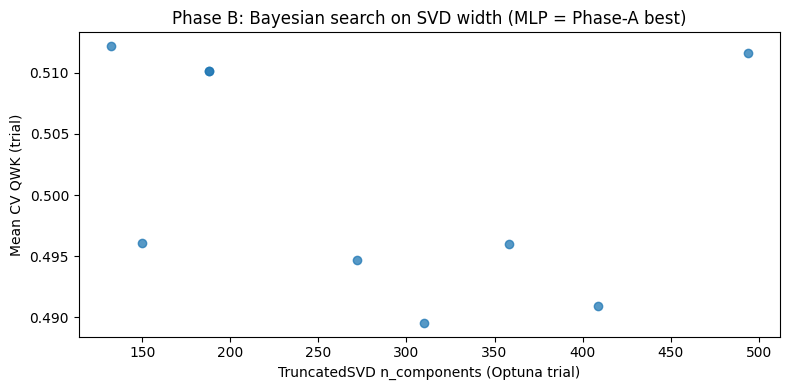

In [14]:
# MLPRegressor + display: §0 Environment Setting.
if "N_CV_SPLITS_OPTUNA" not in globals():
    N_CV_SPLITS_OPTUNA = 5
if "OPTUNA_OBJECTIVE_SUBSAMPLE_N" not in globals():
    OPTUNA_OBJECTIVE_SUBSAMPLE_N = min(6000, len(feature_data_by_source["tfidf"]))
N_SVD_OPTUNA_TRIALS = 15
SVD_N_MIN, SVD_N_MAX = 128, 512  # cap high to <= max_features / rank if sklearn errors

if optuna_study is None:
    print("Phase B skipped (run Phase A first to create optuna_study).")
    svd_study, svd_trials_df = None, None
else:
    bp = optuna_study.best_trial.params
    best_mlp = MLPRegressor(
        hidden_layer_sizes=parse_optuna_mlp_hidden_layer_sizes(bp["hidden_layer_sizes"]),
        alpha=bp["alpha"],
        learning_rate_init=bp["learning_rate_init"],
        batch_size=bp["batch_size"],
        max_iter=bp["max_iter"],
        activation=bp["activation"],
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=CV_RANDOM_STATE,
    )
    svd_study, svd_trials_df = optuna_tune_tfidf_mlp_svd_n_components(
        raw_text_series=feature_data_by_source["tfidf"],
        target_values=y,
        stratification_bins=stratification_bins,
        vectorizer_kwargs=TFIDF_KWARGS,
        mlp_estimator=best_mlp,
        svd_n_components_min=SVD_N_MIN,
        svd_n_components_max=SVD_N_MAX,
        n_trials=N_SVD_OPTUNA_TRIALS,
        n_splits=N_CV_SPLITS_OPTUNA,
        random_state=CV_RANDOM_STATE,
        use_sample_weights=True,
        optuna_seed=CV_RANDOM_STATE,
        use_pruner=True,
        verbose_cv=True,
        limit_blas_threads=True,
        show_progress_bar=True,
        objective_subsample_n=OPTUNA_OBJECTIVE_SUBSAMPLE_N,
    )
    display(rank_optuna_trials_like_cv_leaderboard(svd_trials_df).head(15))
    td = svd_trials_df[np.isfinite(svd_trials_df["qwk_mean"])].copy()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(td["svd_n_components"], td["qwk_mean"], alpha=0.75)
    ax.set_xlabel("TruncatedSVD n_components (Optuna trial)")
    ax.set_ylabel("Mean CV QWK (trial)")
    ax.set_title("Phase B: Bayesian search on SVD width (MLP = Phase-A best)")
    plt.tight_layout()
    plt.show()


## 6 Performance

After §5: test-set metrics on `Data/test.csv`; one pipeline fit on full `Data/train.csv`.

- **SVD width:** `TruncatedSVD(n_components=494)` for the final stack (Phase B `best_trial` rank may be lower; **494** chosen for stabler fold behaviour vs. small mean-QWK differences; hold-out does not use Phase B’s trial rank unless revisited).
- **Test rows:** `filter_by_rater_agreement` is **not** applied on test (deployment-like: no label-based row drops). Scoring still uses `target_vocab` = consensus from `Vocabulary_1` / `Vocabulary_2` on **all** test rows.
- **Protocol:** TF-IDF → SVD(494) → MLP from Phase A `optuna_study.best_trial.params`, early-stopping as in Phase B; **train-only fit**, test = transform + predict; `compute_balanced_sample_weights` on train targets.
- **Outputs:** QWK, RMSE, MAE; predicted vs true scatter; boxplot of continuous preds by true class; row-normalized confusion matrix on rounded preds (0–5).


### 6.1 Test CSV: load and build text/target

No agreement filter; `create_consensus_target` only defines the evaluation label from both raters.

In [18]:
SVD_FINAL_N_COMPONENTS = 494

if "optuna_study" not in globals() or optuna_study is None:
    raise RuntimeError("Run 5.1 Phase A first — optuna_study is required for MLP hyperparameters.")

df_test_raw = pd.read_csv("Data/test.csv")
# Test is not filtered by rater disagreement (unlike train in §2); all rows are scored.
df_test_for_eval = create_consensus_target(df_test_raw.copy())
df_test_text_target = build_text_target_dataset(df_test_for_eval)

X_train_full = feature_data_by_source["tfidf"].reset_index(drop=True)
y_train_full = np.asarray(y, dtype=float).ravel()


### 6.2 Fit TF-IDF + SVD + MLP on full train

In [19]:
optuna_mlp_params = optuna_study.best_trial.params
mlp_final = MLPRegressor(
    hidden_layer_sizes=parse_optuna_mlp_hidden_layer_sizes(optuna_mlp_params["hidden_layer_sizes"]),
    alpha=optuna_mlp_params["alpha"],
    learning_rate_init=optuna_mlp_params["learning_rate_init"],
    batch_size=optuna_mlp_params["batch_size"],
    max_iter=optuna_mlp_params["max_iter"],
    activation=optuna_mlp_params["activation"],
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=CV_RANDOM_STATE,
)

pipeline_final = make_tfidf_mlp_pipeline(
    vectorizer_kwargs=TFIDF_KWARGS,
    n_svd_components=SVD_FINAL_N_COMPONENTS,
    mlp_estimator=mlp_final,
    random_state=CV_RANDOM_STATE,
)

train_sample_weights = compute_balanced_sample_weights(y_train_full.astype(int))
pipeline_final.fit(
    X_train_full,
    y_train_full,
    mlp__sample_weight=train_sample_weights,
)


,steps,"[('tfidf', ...), ('svd', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


### 6.3 Test-set predictions and metrics

In [20]:
X_test_eval = df_test_text_target["Text_cleaned"].reset_index(drop=True)
y_test_eval = np.asarray(df_test_text_target["target_vocab"].values, dtype=int)
y_pred_test = pipeline_final.predict(X_test_eval)

test_metrics = evaluate_fold(y_test_eval, y_pred_test, min_score=0, max_score=5)
summary_df_test = (
    pd.DataFrame([test_metrics], index=["Test set"])
    .rename(columns={"qwk": "QWK", "rmse": "RMSE", "mae": "MAE"})
)
display(summary_df_test)


,QWK,RMSE,MAE
Test set,0.532867,0.708233,0.569546


### 6.4 Diagnostic plots (predicted vs true, boxplot by true class)

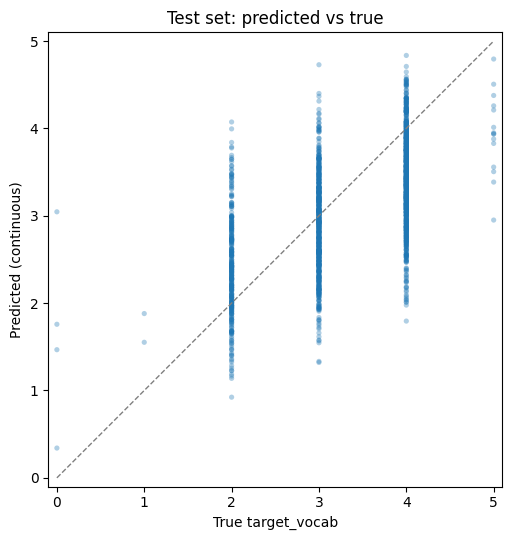

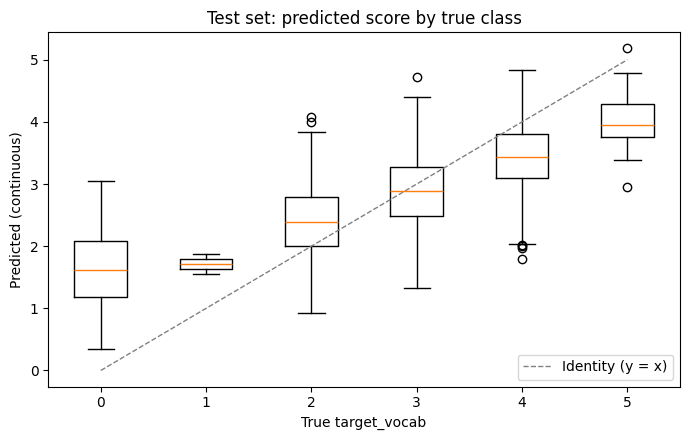

In [27]:
fig_scatter_test = plot_ordinal_predicted_vs_true_scatter(
    y_test_eval,
    y_pred_test,
    title="Test set: predicted vs true",
    xlabel="True target_vocab",
)
plt.show()

fig_box_test = plot_ordinal_continuous_boxplot_by_true_class(
    y_test_eval,
    y_pred_test,
    title="Test set: predicted score by true class",
    xlabel="True target_vocab",
)
plt.show()


### 6.5 Confusion matrix — row-normalized (rounded predictions)

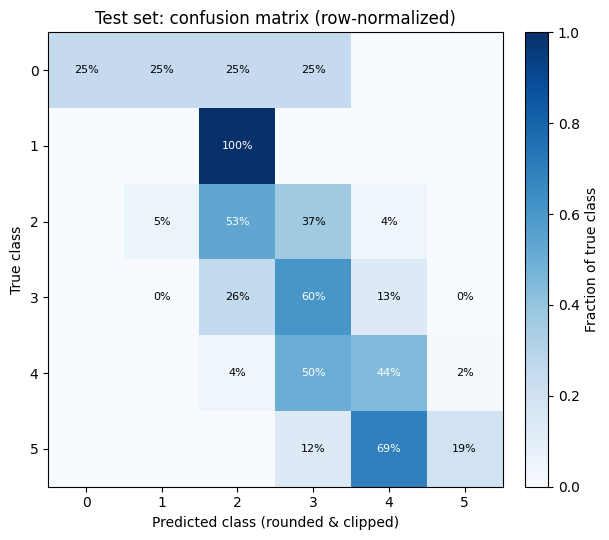

In [28]:
y_pred_ordinal_test = round_and_clip_predictions(y_pred_test, 0, 5)
ordinal_class_labels = np.arange(0, 6)
fig_cm_test = plot_row_normalized_confusion_matrix_from_labels(
    y_test_eval,
    y_pred_ordinal_test,
    labels=ordinal_class_labels,
    title="Test set: confusion matrix (row-normalized)",
    xlabel="Predicted class (rounded & clipped)",
)
plt.show()
